In [1]:
import numpy as np
import pandas as pd
import geopandas as gpd
from pyproj import Transformer
from shapely.geometry import Point, LineString, Polygon
import utils
from shapely import wkt
import matplotlib.pyplot as plt

import pyvista as pv
pv.set_jupyter_backend('static')


In [2]:
ls =  "LINESTRING (-68.8 43.7, -68.2 43.95, -67.6 43.75, -67.0 44.0)" 
geom = wkt.loads(ls)
line_gdf = gpd.GeoDataFrame(geometry=[geom], crs=utils.wgs84)

In [3]:
gebco_dir = "../opprotunisticsonarscan/gebco_contour/"

In [4]:
beam = utils.load_beam("./EM302nautilus.txt")

In [5]:
max_width = utils.max_width(beam)
envelope = utils.line_to_ellipse(line_gdf, width=max_width*1.1, resolution = 4)  # Example width of 100 km+
m = utils.Map(envelope, gebco_dir, extinction_file="EM302nautilus.txt")

In [6]:
grid = m.polygonize_seafloor()

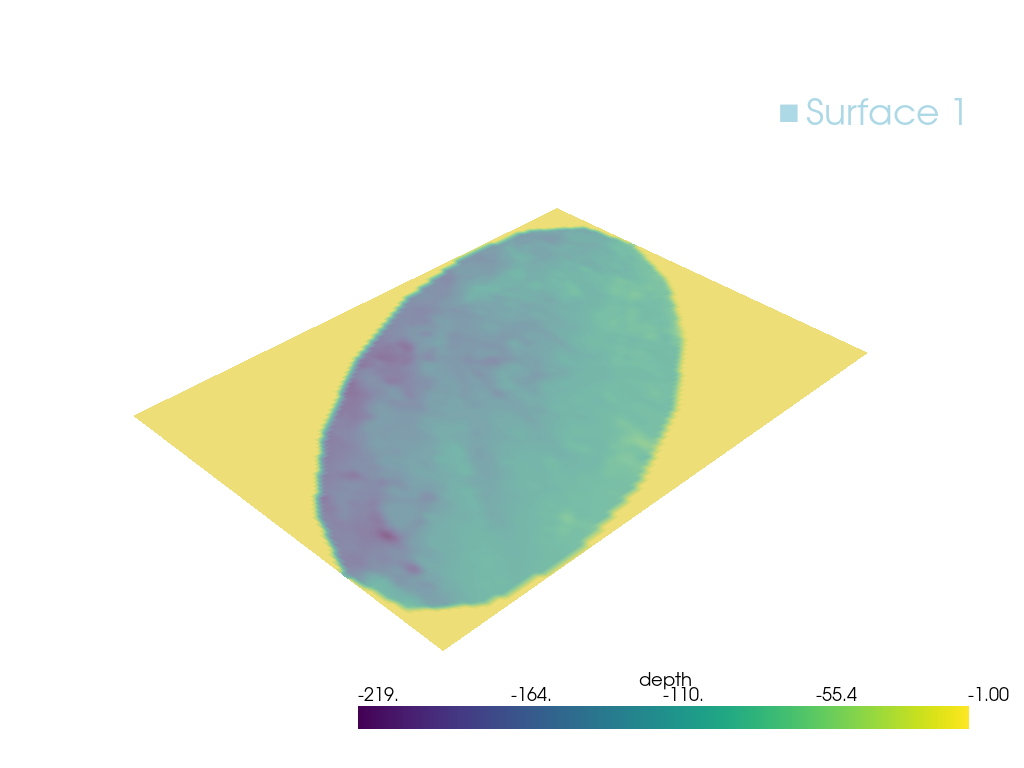

In [8]:
plotter = pv.Plotter(off_screen=True)
plotter.add_mesh(grid, cmap='viridis', opacity=0.6, label='Surface 1')
plotter.add_legend()
plotter.show()